# F1 Pit Stop Prediction — Training Framework

Binary classification: predict `PitNextLap` (whether the driver pits on the next lap).

Pipeline: load → EDA → preprocess → CV training → submission.

EDA lives in `eda.ipynb`. This notebook covers feature engineering, cross-validated training, and submission.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

import lightgbm as lgb

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42
DATA_DIR = Path('.')

/home/propar/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Load data

In [2]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

TARGET = 'PitNextLap'
ID_COL = 'id'

print('train:', train.shape, '| test:', test.shape)
train.head()

train: (439140, 16) | test: (188165, 15)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 3. Feature engineering

In [3]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values(['Race', 'Year', 'Driver', 'LapNumber']).reset_index(drop=True)

    stint_key = ['Race', 'Year', 'Driver', 'Stint']
    drv_key   = ['Race', 'Year', 'Driver']
    race_key  = ['Race', 'Year']

    # --- Stint dynamics ---
    df['LapsInStint'] = df.groupby(stint_key).cumcount() + 1
    g_stint_lap   = df.groupby(stint_key, sort=False)['LapTime (s)']
    g_stint_delta = df.groupby(stint_key, sort=False)['LapTime_Delta']

    df['Stint_LapTime_mean_sofar'] = g_stint_lap.transform(lambda s: s.expanding().mean())
    df['Stint_LapTime_std_sofar']  = g_stint_lap.transform(lambda s: s.expanding().std())
    df['LapTime_vs_StintMean']     = df['LapTime (s)'] - df['Stint_LapTime_mean_sofar']

    for w in (3, 5):
        df[f'Delta_roll{w}_mean'] = g_stint_delta.transform(lambda s: s.rolling(w, min_periods=1).mean())
        df[f'Delta_roll{w}_std']  = g_stint_delta.transform(lambda s: s.rolling(w, min_periods=2).std())
        df[f'Lap_roll{w}_mean']   = g_stint_lap.transform(lambda s: s.rolling(w, min_periods=1).mean())

    # last-5-lap slope of LapTime (degradation trend) -- rolling regression slope
    def _slope_win(arr):
        n = len(arr)
        x = np.arange(n)
        xm = x.mean(); ym = arr.mean()
        denom = ((x - xm) ** 2).sum()
        if denom == 0:
            return np.nan
        return ((x - xm) * (arr - ym)).sum() / denom
    df['LapTime_slope5'] = g_stint_lap.transform(
        lambda s: s.rolling(5, min_periods=2).apply(_slope_win, raw=True))

    # --- Race context ---
    df['TotalLaps']     = df.groupby(race_key)['LapNumber'].transform('max')
    df['LapsRemaining'] = df['TotalLaps'] - df['LapNumber']
    df['IsLateRace']    = (df['RaceProgress'] > 0.7).astype('int8')
    df['IsVeryLate']    = (df['RaceProgress'] > 0.85).astype('int8')

    # --- Position dynamics ---
    df['PosChange_roll3'] = df.groupby(drv_key, sort=False)['Position_Change'].transform(
        lambda s: s.rolling(3, min_periods=1).mean())
    df['Position_vs_StintStart'] = df['Position'] - df.groupby(stint_key, sort=False)['Position'].transform('first')

    # --- Compound expectations: typical stint length per (Race, Compound) ---
    stint_lengths = df.groupby(stint_key, sort=False)['LapNumber'].transform('count')
    df['_StintLen_total'] = stint_lengths
    comp_table = (df.groupby(['Race', 'Compound'], observed=True)['_StintLen_total']
                    .mean().rename('Compound_typical_stint').reset_index())
    df = df.merge(comp_table, on=['Race', 'Compound'], how='left')
    df['TyreLife_vs_typical'] = df['TyreLife'] - df['Compound_typical_stint']
    df['StintProgress'] = df['LapsInStint'] / df['Compound_typical_stint'].replace(0, np.nan)
    df.drop(columns=['_StintLen_total'], inplace=True)

    # --- Neighbor pit pressure ---
    pits_per_lap = df.groupby(['Race', 'Year', 'LapNumber'])['PitStop'].transform('sum')
    df['FieldPits_thisLap'] = pits_per_lap - df['PitStop']
    df['FieldPits_prevLap'] = df.groupby(drv_key, sort=False)['FieldPits_thisLap'].shift(1).fillna(0)

    # --- Driver pit history within race ---
    df['DriverPits_sofar'] = df.groupby(drv_key, sort=False)['PitStop'].cumsum() - df['PitStop']

    return df

train_fe = add_features(train)
test_fe  = add_features(test)

CAT_COLS = ['Driver', 'Compound', 'Race']
DROP_COLS = [ID_COL, TARGET, 'LapNumber']
FEATURES = [c for c in train_fe.columns if c not in DROP_COLS]

for c in CAT_COLS:
    train_fe[c] = train_fe[c].astype('category')
    test_fe[c]  = test_fe[c].astype('category')

print(f'{len(FEATURES)} features')
print(FEATURES)


36 features
['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'LapsInStint', 'Stint_LapTime_mean_sofar', 'Stint_LapTime_std_sofar', 'LapTime_vs_StintMean', 'Delta_roll3_mean', 'Delta_roll3_std', 'Lap_roll3_mean', 'Delta_roll5_mean', 'Delta_roll5_std', 'Lap_roll5_mean', 'LapTime_slope5', 'TotalLaps', 'LapsRemaining', 'IsLateRace', 'IsVeryLate', 'PosChange_roll3', 'Position_vs_StintStart', 'Compound_typical_stint', 'TyreLife_vs_typical', 'StintProgress', 'FieldPits_thisLap', 'FieldPits_prevLap', 'DriverPits_sofar']


## 4. Cross-validation training

Group by `(Race, Year, Driver)` so the same stint doesn't leak across folds.

In [4]:
X = train_fe[FEATURES]
y = train_fe[TARGET]
groups = (train_fe['Race'].astype(str) + '_' + train_fe['Year'].astype(str) + '_' + train_fe['Driver'].astype(str))
X_test = test_fe[FEATURES]

params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.9,
    'bagging_freq': 5,
    'min_data_in_leaf': 100,
    'verbose': -1,
    'seed': RANDOM_STATE,
}

N_SPLITS = 5
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof = np.zeros(len(train_fe))
test_pred = np.zeros(len(test_fe))
feat_importance = pd.DataFrame(index=FEATURES)

for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y, groups)):
    dtr = lgb.Dataset(X.iloc[tr_idx], y.iloc[tr_idx], categorical_feature=CAT_COLS)
    dva = lgb.Dataset(X.iloc[va_idx], y.iloc[va_idx], categorical_feature=CAT_COLS)
    model = lgb.train(
        params, dtr,
        num_boost_round=3000,
        valid_sets=[dva],
        callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)],
    )
    oof[va_idx] = model.predict(X.iloc[va_idx])
    test_pred += model.predict(X_test) / N_SPLITS
    feat_importance[f'fold{fold}'] = model.feature_importance(importance_type='gain')
    print(f'Fold {fold} AUC = {roc_auc_score(y.iloc[va_idx], oof[va_idx]):.5f}')

print('\nOOF AUC :', roc_auc_score(y, oof))
print('OOF AP  :', average_precision_score(y, oof))
print('OOF LL  :', log_loss(y, oof))

Training until validation scores don't improve for 100 rounds


[200]	valid_0's auc: 0.940055


[400]	valid_0's auc: 0.941294


[600]	valid_0's auc: 0.941581


[800]	valid_0's auc: 0.941771


...

[600]	valid_0's auc: 0.940957


[800]	valid_0's auc: 0.941107


[1000]	valid_0's auc: 0.9413


Early stopping, best iteration is:
[1063]	valid_0's auc: 0.941355


Fold 4 AUC = 0.94135

OOF AUC : 0.9408998264921147
OOF AP  : 0.7868893073722194
OOF LL  : 0.24214295461227636


## 5. Feature importance

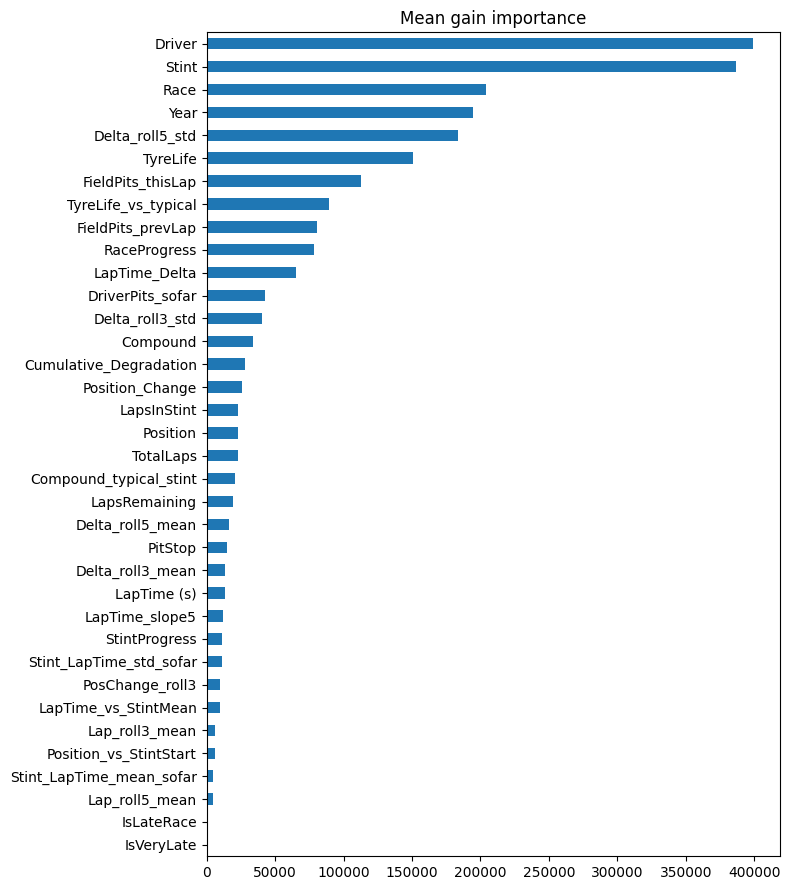

In [5]:
imp = feat_importance.mean(axis=1).sort_values(ascending=True)
plt.figure(figsize=(8, max(4, len(imp) * 0.25))); imp.plot.barh(); plt.title('Mean gain importance'); plt.tight_layout(); plt.show()

## 6. Submission

In [6]:
submission = sample_submission.copy()
submission[TARGET] = test_pred
submission.to_csv('submission.csv', index=False)
submission.head()

,id,PitNextLap
0,439140,0.021029
1,439141,0.031560
2,439142,0.391039
3,439143,0.464971
4,439144,0.279569
